In [7]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import itertools
import seaborn as sns
from itertools import combinations
import numpy as np

In [8]:
with open("configs/ingredients.json", "r") as f:
    ingredients = json.load(f)

with open("configs/init_recipes.json", "r") as f:
    inspiration = json.load(f)

with open("configs/overall_configs.json", "r") as f:
    configs = json.load(f)

with open("configs/flavor_pairings.json", "r") as f:
    flavor_pairs = json.load(f)

print(f"Ingredients loaded: {len(ingredients)}")
print(f"Seed recipes loaded: {len(inspiration['seed_recipes'])}")
print(f"Flavor pairings loaded: {len(flavor_pairs)}")

Ingredients loaded: 95
Seed recipes loaded: 37
Flavor pairings loaded: 1995


# Ingredients

,id,name,roles,category,flavor_notes
0,flour_ap,All-purpose flour,base,dry,
1,flour_almond,Almond flour,base,dry,almond
2,flour_oat,Oat flour,base,dry,oat
3,flour_coconut,Coconut flour,base,dry,coconut
4,flour_wholewheat,Whole wheat flour,base,dry,graham


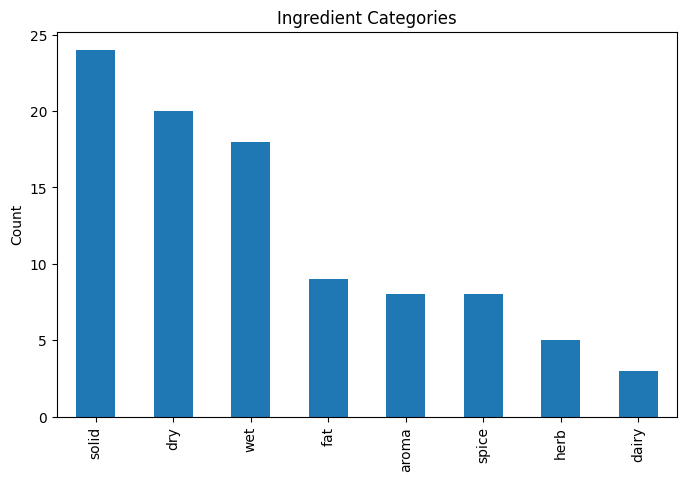

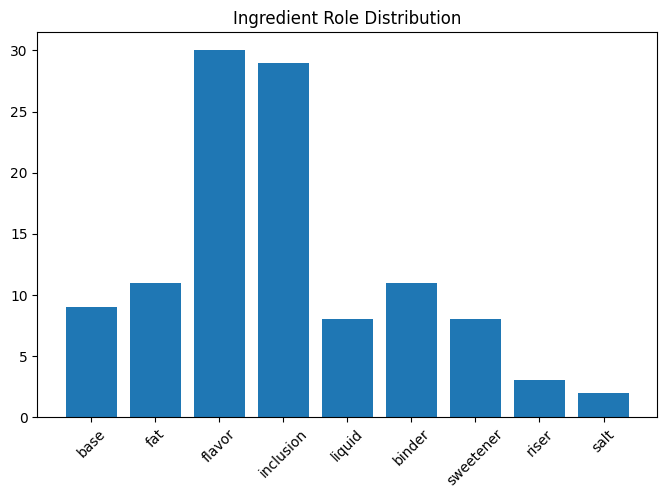

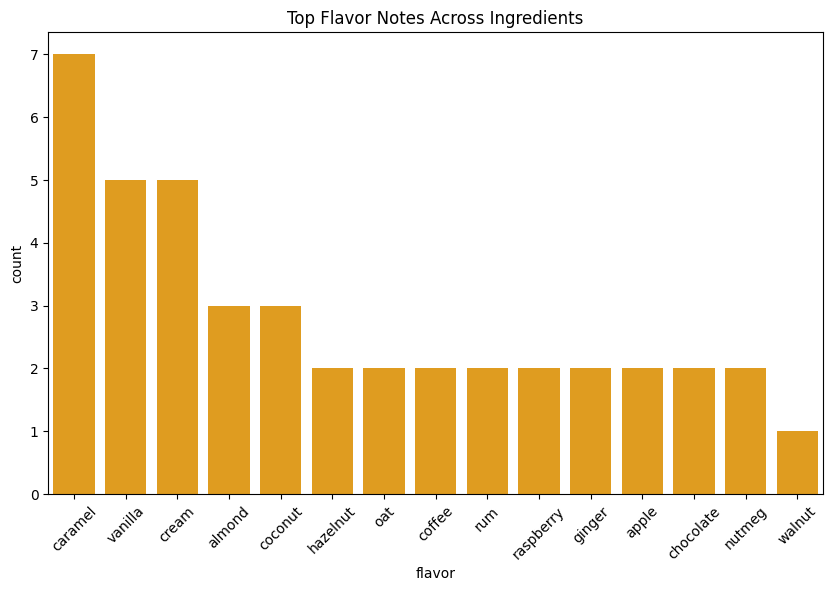

In [9]:
ingredient_df = pd.DataFrame([
    {
        "id": k,
        "name": v["name"],
        "roles": ", ".join(v["roles"]),
        "category": v["category"],
        "flavor_notes": ", ".join(v["flavor_notes"])
    } for k, v in ingredients.items()
])

display(ingredient_df.head())

# --- Count by category
plt.figure(figsize=(8,5))
ingredient_df["category"].value_counts().plot(kind="bar")
plt.title("Ingredient Categories")
plt.ylabel("Count")
plt.show()

# --- Count by role
all_roles = list(itertools.chain.from_iterable([v["roles"] for v in ingredients.values()]))
role_counts = Counter(all_roles)

plt.figure(figsize=(8,5))
plt.bar(role_counts.keys(), role_counts.values())
plt.xticks(rotation=45)
plt.title("Ingredient Role Distribution")
plt.show()

# --- Count by flavor notes
flavors = list(itertools.chain.from_iterable([v["flavor_notes"] for v in ingredients.values()]))
flavor_counts = Counter(flavors)
flavor_df = pd.DataFrame(flavor_counts.items(), columns=["flavor", "count"]).sort_values("count", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=flavor_df.head(15), x="flavor", y="count", color="orange")
plt.title("Top Flavor Notes Across Ingredients")
plt.xticks(rotation=45)
plt.show()

# Recipes

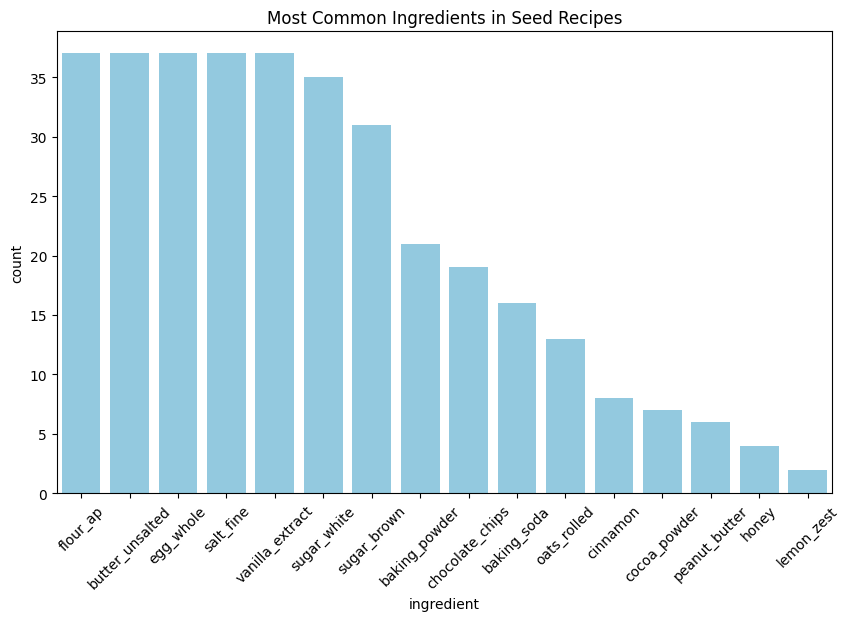

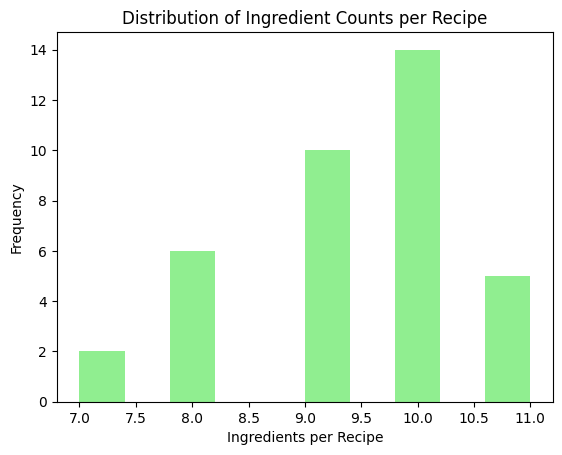

In [10]:
recipes = inspiration["seed_recipes"]

# ingredient usage frequency
ingredient_usage = Counter()
for r in recipes:
    ingredient_usage.update(r["ingredients_g"].keys())

usage_df = pd.DataFrame(ingredient_usage.items(), columns=["ingredient", "count"]).sort_values("count", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=usage_df.head(20), x="ingredient", y="count", color="skyblue")
plt.title("Most Common Ingredients in Seed Recipes")
plt.xticks(rotation=45)
plt.show()

# recipe ingredient count distribution
ingredient_counts = [len(r["ingredients_g"]) for r in recipes]
plt.hist(ingredient_counts, bins=10, color="lightgreen")
plt.title("Distribution of Ingredient Counts per Recipe")
plt.xlabel("Ingredients per Recipe")
plt.ylabel("Frequency")
plt.show()


# Flavor pairings

In [11]:
# Extract all unique flavor names from both columns
flavors = set()
for p in flavor_pairs:
    flavors.add(p["flavor"].strip().lower())
    flavors.add(p["flavor2"].strip().lower())

# Sort alphabetically
unique_flavors = sorted(flavors)

print(f"Total unique flavors: {len(unique_flavors)}")

print(unique_flavors)

Total unique flavors: 98
['allspice', 'almond', 'anise', 'apple', 'apricot', 'avocado', 'banana', 'basil', 'bay', 'blackberry', 'blueberry', 'brandy', 'caramel', 'cardamom', 'carrot', 'cashew', 'cayenne', 'chai', 'chamomile', 'champagne', 'cherry', 'chestnut', 'chocolate', 'cilantro', 'cinnamon', 'clove', 'cocoa', 'coconut', 'coffee', 'cola', 'cranberry', 'cream', 'cucumber', 'curry', 'date', 'earl', 'expresso', 'fennel', 'fig', 'garlic', 'ginger', 'gingerbread', 'graham', 'grape', 'hazelnut', 'herbal', 'hibiscus', 'honey', 'lavender', 'lemon', 'lemongrass', 'lime', 'mango', 'maple', 'marshmallow', 'mascarpone', 'matcha', 'mint', 'mochi', 'nutmeg', 'oat', 'oatmeal', 'orange', 'parsley', 'passionfruit', 'peach', 'peanut', 'pear', 'pecan', 'pepper', 'pineapple', 'pistachio', 'plum', 'pomegranate', 'pretzel', 'pumpkin', 'raisin', 'raspberry', 'rhubarb', 'ricotta', 'rose', 'rosemary', 'rum', 'saffron', 'sage', 'strawberry', 'tahini', 'tarragon', 'tequila', 'thyme', 'tomato', 'vanilla', 'vo

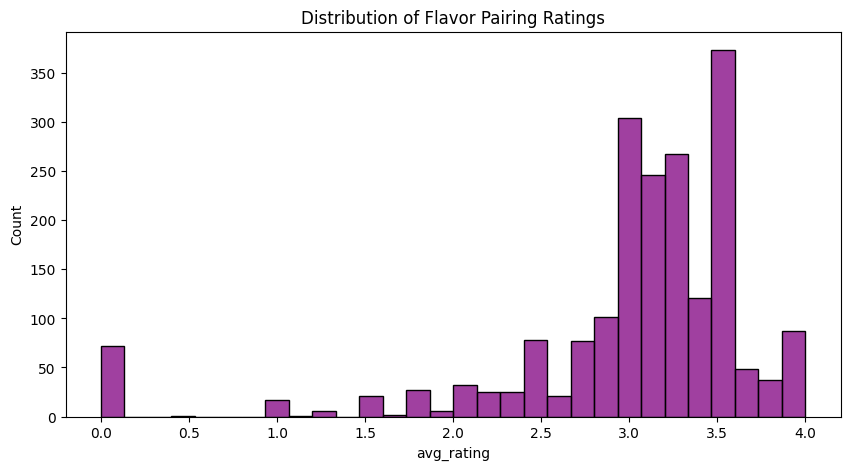

,flavor,flavor2,avg_rating
0,anise,brandy,4.0
54,blackberry,fig,4.0
62,anise,raisin,4.0
61,bay,fig,4.0
60,raspberry,thyme,4.0
59,cashew,cherry,4.0
58,chamomile,strawberry,4.0
57,cardamom,cucumber,4.0
56,mango,ricotta,4.0
55,avocado,walnut,4.0


In [12]:
flavor_pair_df = pd.DataFrame(flavor_pairs)
flavor_pair_df["avg_rating"] = flavor_pair_df["avg_rating"].astype(float)

plt.figure(figsize=(10,5))
sns.histplot(flavor_pair_df["avg_rating"], bins=30, color="purple")
plt.title("Distribution of Flavor Pairing Ratings")
plt.xlabel("avg_rating")
plt.show()

# top pairings
top_pairs = flavor_pair_df.sort_values("avg_rating", ascending=False).head(20)
display(top_pairs[["flavor", "flavor2", "avg_rating"]])
